# Lecture 3.6 — Tool Output Types: Returning Images, Files, and Structured Data

**Course:** OpenAI Agents SDK — Complete Course  
**Section:** 03 — Tools: Extending Agent Capabilities

Every tool we have written so far returns a plain string. The SDK supports three richer output types: `ToolOutputText`, `ToolOutputImage`, and `ToolOutputFileContent`. These let a tool pass images the model can see, files the model can read, and explicitly-typed text that can be combined with both.

By the end of this notebook you will understand:
- How the SDK decides what to send to the model for any tool return value
- `ToolOutputText` — explicit text output and why it exists
- `ToolOutputImage` — images via public URL and via base64 data URL
- `ToolOutputFileContent` — passing a file for the model to read
- Mixed list returns — text and image combined in a single tool call
- The all-or-nothing list rule and why it matters

## Cell 1 — Install the SDK

📌 **Notebook update notice:** this lecture's markdown references `openai-agents==0.17.8` as the pinned version. Since recording, a downstream dependency change (`openai>=2.45.0`, released July 9, 2026) broke `openai-agents` versions below 0.18.1 — `Runner.run()` will fail on the version stated above. This notebook has been updated to pin `openai-agents==0.18.3`, which fixes the issue without changing any of the code or concepts taught in the lecture. Please use the version pinned below, not the one mentioned in the recording.

This cell installs `openai-agents`, the only non-standard dependency this notebook requires. The version is pinned to **0.18.3** so every example runs exactly as written.

> **To use a different version:** Replace `==0.18.3` with your preferred version, or remove the pin entirely to get the latest release.

In [ ]:
# Pinned for reproducibility. Updated after recording — see the
# notice above. Originally pinned to 0.17.8 as stated in the
# video; updated to 0.18.3 to fix a breaking change introduced
# by openai>=2.45.0 (July 9, 2026).
# To use the latest version instead, run: pip install openai-agents
!pip install openai-agents==0.18.3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.6/859.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.1 MB/s eta 0:00:00


## Cell 2 — API Key Setup

This notebook reads your OpenAI API key from **Google Colab Secrets**.

### Steps to add your key
1. Click the **key icon** in the left sidebar (or go to *Tools → Secrets*).
2. Click **+ Add new secret**.
3. Set **Name** to `OPENAI_API_KEY`.
4. Paste your key as the **Value**.
5. Toggle **Notebook access** to ON.
6. Run the cell below.

### Running locally?
Set the environment variable in your terminal before launching Jupyter:
```bash
export OPENAI_API_KEY="sk-..."
```

In [ ]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

## Cell 3 — Model Name

`MODEL_NAME` is declared once and used in every `Agent` definition. Change this one line to switch the model across the entire notebook.

`gpt-5.4-mini` supports both text and vision inputs. Vision support is required for `ToolOutputImage` cells to work correctly — a text-only model cannot process image content.

> **See all available models:** https://platform.openai.com/docs/models

In [ ]:
# See latest models at: https://platform.openai.com/docs/models
MODEL_NAME = "gpt-5.4-mini"

## Cell 4 — Imports

| Import | From | Purpose |
|--------|------|---------|
| `base64` | stdlib | Encode bytes as base64 strings for data URIs |
| `io` | stdlib | In-memory byte buffers for matplotlib output |
| `matplotlib` | third-party | Generate charts to send as images |
| `requests` | third-party | Fetch image bytes from a URL to display inline |
| `IPython.display` | Colab/Jupyter | Render images inline in the cell output |
| `Reasoning` | `openai.types.shared` | Configure reasoning effort on GPT-5 models |
| `Agent` | `agents` | Define agents with instructions, tools, and model settings |
| `ModelSettings` | `agents` | Pass reasoning effort and verbosity to the model |
| `Runner` | `agents` | Execute agent runs with `await Runner.run()` |
| `ToolOutputFileContent` | `agents` | Return a file — base64 data URI, URL, or uploaded file ID |
| `ToolOutputImage` | `agents` | Return an image — URL, data URL, or uploaded file ID |
| `ToolOutputText` | `agents` | Return explicitly-typed text |
| `function_tool` | `agents` | Decorator that registers a Python function as a tool |

All three `ToolOutput` types import directly from the `agents` top-level package.

In [ ]:
import base64
import io

import matplotlib
import matplotlib.pyplot as plt
import requests
from IPython.display import display, Image as IPImage

matplotlib.use("Agg")  # Non-interactive backend, safe in Colab

from openai.types.shared import Reasoning

from agents import (
    Agent,
    ModelSettings,
    Runner,
    ToolOutputFileContent,
    ToolOutputImage,
    ToolOutputText,
    function_tool,
)

## How the SDK Converts Tool Return Values

Before writing any tool, it helps to understand exactly what the SDK does with whatever a tool returns. This logic lives in `src/agents/items.py` in `_convert_tool_output`.

### Conversion rules

| What the tool returns | What the model receives |
|-----------------------|-------------------------|
| `str` or any plain object | `str(value)` — plain text (every tool in lectures 3.1–3.5) |
| `ToolOutputText`, `ToolOutputImage`, or `ToolOutputFileContent` | Converted to Responses API structured format |
| `list` / `tuple` where **every** item is one of those types | All items as a multi-content payload |
| `list` / `tuple` where **any** item is not one of those types | `str(list)` — the whole list is stringified |
| `dict` with a `"type"` key of `"text"`, `"image"`, or `"file"` | Validated and converted |
| `dict` without a `"type"` key | `str(dict)` — not detected as structured |

### The all-or-nothing rule

The list rule is strict. Every item in a returned list must be a recognised SDK type. If even one item is not, the entire list is stringified. This is why `ToolOutputText` exists — a plain `str` would fail the check, but `ToolOutputText(text=...)` passes it, allowing text to join a list alongside images and files.

## Cell 5 — `ToolOutputText`: Explicit Text Output

`ToolOutputText` wraps a string in an explicitly-typed text block.

### Fields

| Field | Type | Default | Notes |
|-------|------|---------|-------|
| `type` | `Literal["text"]` | `"text"` | Auto-set by Pydantic. Never pass manually. |
| `text` | `str` | — | Required. The text content. |

On its own, `ToolOutputText(text=...)` produces the same model input as returning a plain `str`. Its real purpose becomes clear in Cell 9: it is the type that allows plain text to participate in a mixed list alongside images, passing the all-or-nothing validation check.

In [ ]:
@function_tool
def get_product_summary(product_name: str) -> ToolOutputText:
    """Returns a formatted product summary as explicit text.

    Args:
        product_name: The name of the product to summarise.
    """
    return ToolOutputText(
        text=(
            f"Product: {product_name}\n"
            f"Category: Electronics\n"
            f"Price: $299.99\n"
            f"Rating: 4.7/5 (1,243 reviews)\n"
            f"Status: In Stock"
        )
    )


agent = Agent(
    name="Product Agent",
    instructions=(
        "You are a product information assistant. "
        "Use the get_product_summary tool to answer product questions."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_product_summary],
)

result = await Runner.run(
    agent,
    "Tell me about the iPhone 16.",
)
print(result.final_output)

iPhone 16

- Category: Electronics
- Price: $299.99
- Rating: 4.7/5 (1,243 reviews)
- Status: In Stock


## Cell 6 — `ToolOutputImage`: Returning an Image via URL

`ToolOutputImage` passes an actual image into the model's context. The model sees and reasons about the visual content — it does not receive a URL string to read.

### Fields

| Field | Type | Default | Notes |
|-------|------|---------|-------|
| `type` | `Literal["image"]` | `"image"` | Auto-set. Never pass manually. |
| `image_url` | `str \| None` | `None` | A public URL or a `data:image/...;base64,...` data URL |
| `file_id` | `str \| None` | `None` | An OpenAI Files API file ID for a previously uploaded image |
| `detail` | `Literal["low","high","auto"] \| None` | `None` | Vision processing level. `"low"` is faster and cheaper. `"high"` is better for complex visuals or small text. |

**Validation:** At least one of `image_url` or `file_id` must be provided. A Pydantic `@model_validator` enforces this at construction time — passing neither raises `ValueError` before the model is called.

The tool also calls `display(IPImage(...))` so the image the learner sees in the cell output is the same image the model receives.

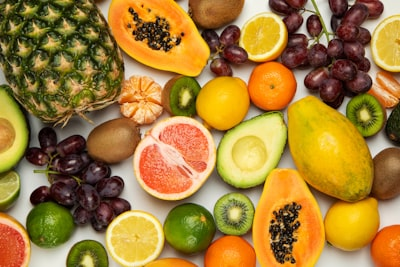

Here’s the product image for fresh produce:

A colorful assortment of fruits spread across a white background, including pineapple, papaya, avocado, kiwi, grapes, citrus fruits, mango, and melon. The image looks bright, fresh, and vibrant.


In [ ]:
@function_tool
def get_product_image(product_name: str) -> ToolOutputImage:
    """Returns a product image for the given product.

    Args:
        product_name: The name of the product.
    """
    image_url = "https://images.unsplash.com/photo-1610832958506-aa56368176cf?w=400&q=80"

    # Display the image in the notebook so the learner sees what was sent to the model
    img_bytes = requests.get(image_url).content
    display(IPImage(data=img_bytes))

    return ToolOutputImage(
        image_url=image_url,
        detail="low",
    )


image_agent = Agent(
    name="Image Product Agent",
    instructions=(
        "You are a product visual assistant. "
        "Use the get_product_image tool and describe what you see in the image."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_product_image],
)

result = await Runner.run(
    image_agent,
    "Show me the product image for fresh produce.",
)
print(result.final_output)

## Cell 7 — `ToolOutputImage`: Base64 Data URL for Programmatic Images

The `image_url` field accepts **data URLs** — self-contained strings that embed image bytes directly, with no external hosting required:

```
data:image/png;base64,<base64-encoded-bytes>
```

### Workflow for programmatically generated images

1. Generate the image in memory (e.g. `matplotlib`, `Pillow`)
2. Write the bytes to a `BytesIO` buffer
3. Base64-encode: `base64.b64encode(buf.getvalue()).decode("utf-8")`
4. Prefix: `f"data:image/png;base64,{b64}"`
5. Return `ToolOutputImage(image_url=data_url)`

The tool calls `display(IPImage(data=png_bytes))` so the chart the learner sees is exactly the image sent to the model — from the same bytes, before encoding.

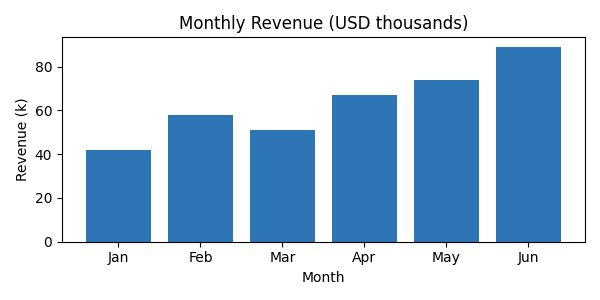

The chart shows monthly revenue trending upward overall, with a small dip in March after February, then steady growth through June.

- Lowest point: January
- Highest point: June
- Notable pattern: strong month-to-month increase after March

It looks like a healthy upward revenue trend.


In [ ]:
@function_tool
def generate_revenue_chart(data_description: str) -> ToolOutputImage:
    """Generates a bar chart of monthly revenue and returns it as a data URL.

    Args:
        data_description: A description of the data being charted.
    """
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
    revenue = [42, 58, 51, 67, 74, 89]

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(months, revenue, color="#2E75B6")
    ax.set_title("Monthly Revenue (USD thousands)")
    ax.set_ylabel("Revenue (k)")
    ax.set_xlabel("Month")
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    png_bytes = buf.getvalue()

    # Display the chart inline so the learner sees what was sent to the model
    display(IPImage(data=png_bytes))

    b64_data = base64.b64encode(png_bytes).decode("utf-8")
    data_url = f"data:image/png;base64,{b64_data}"

    return ToolOutputImage(
        image_url=data_url,
        detail="low",
    )


chart_agent = Agent(
    name="Chart Agent",
    instructions=(
        "You are a data visualisation assistant. "
        "Use the generate_revenue_chart tool and describe what you see in the chart."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[generate_revenue_chart],
)

result = await Runner.run(
    chart_agent,
    "Generate a monthly revenue chart and describe what you see.",
)
print(result.final_output)

## Cell 8 — `ToolOutputFileContent`: Returning a File

`ToolOutputFileContent` gives the model a file to read. The model receives the actual document content — not a description or summary of it.

### Fields

| Field | Type | Default | Notes |
|-------|------|---------|-------|
| `type` | `Literal["file"]` | `"file"` | Auto-set. Never pass manually. |
| `file_data` | `str \| None` | `None` | A base64 **data URI** — must include the MIME type prefix |
| `file_url` | `str \| None` | `None` | URL to a hosted file |
| `file_id` | `str \| None` | `None` | An OpenAI Files API file ID |
| `filename` | `str \| None` | `None` | Optional filename hint, e.g. `"report.md"` |

**Validation:** At least one of `file_data`, `file_url`, or `file_id` must be provided.

### The data URI format for `file_data`

`file_data` must be a full data URI, not a raw base64 string. The Responses API requires the MIME type prefix:

```python
# Correct
file_data = f"data:text/plain;base64,{raw_b64}"

# Wrong — causes a 400 error
file_data = raw_b64
```

Use `data:text/plain;base64,...` for plain text and Markdown. Use `data:application/pdf;base64,...` for PDFs.

In [ ]:
@function_tool
def get_report_file(report_name: str) -> ToolOutputFileContent:
    """Returns a report as a file for the model to read.

    Args:
        report_name: The name of the report to retrieve.
    """
    report_content = (
        f"# {report_name}\n\n"
        f"## Executive Summary\n"
        f"Q4 2024 performance exceeded targets by 15%.\n\n"
        f"## Key Metrics\n"
        f"- Revenue: $4.2M (+22% YoY)\n"
        f"- Active Users: 128,000 (+35% YoY)\n"
        f"- NPS Score: 68 (industry average: 45)\n\n"
        f"## Recommendations\n"
        f"Increase marketing spend in the APAC region."
    )
    raw_b64 = base64.b64encode(
        report_content.encode("utf-8")
    ).decode("utf-8")

    # The Responses API requires a full data URI, not a raw base64 string
    file_data = f"data:text/plain;base64,{raw_b64}"

    safe_name = report_name.lower().replace(" ", "_")
    return ToolOutputFileContent(
        file_data=file_data,
        filename=f"{safe_name}.md",
    )


file_agent = Agent(
    name="Report Agent",
    instructions=(
        "You are a report analysis assistant. "
        "Use the get_report_file tool to retrieve reports "
        "and answer questions about their contents."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_report_file],
)

result = await Runner.run(
    file_agent,
    "Get the Q4 Performance report and summarise the key metrics.",
)
print(result.final_output)

Q4 Performance summary:
- Performance exceeded targets by 15%
- Revenue: $4.2M (+22% YoY)
- Active Users: 128,000 (+35% YoY)
- NPS Score: 68 (industry average: 45)

Recommendation: increase marketing spend in APAC.


## Cell 9 — Mixed List Return: Text and Image in Sync

A single tool call can return a **list** of output types. The SDK converts all items as a multi-content payload in a single context update.

### The all-or-nothing rule

| Condition | Result |
|-----------|--------|
| Every item is `ToolOutputText`, `ToolOutputImage`, or `ToolOutputFileContent` | Multi-content payload |
| Any item is not a recognised type | `str(list)` — entire list stringified |

This is why `ToolOutputText` is used for the description rather than a plain `str`. A plain string would fail the check and cause the whole list to be stringified.

### Keeping text and image in sync

Both the text description and the image URL are looked up from the same `PRODUCT_CATALOG` entry. The description and the image always refer to the same product, regardless of which product name the agent passes in.

The tool calls `display(IPImage(...))` inside the function so the image appears in the cell output at the moment the tool runs — before the agent's final response prints.

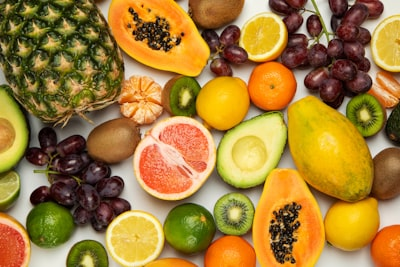

Fruit Basket  
Category: Groceries  
Price: $12.99  
Status: In Stock


In [ ]:
PRODUCT_CATALOG = {
    "fruit basket": {
        "category": "Groceries",
        "price": "$12.99",
        "status": "In Stock",
        "image_url": "https://images.unsplash.com/photo-1610832958506-aa56368176cf?w=400&q=80",
    },
    "laptop": {
        "category": "Electronics",
        "price": "$999.99",
        "status": "In Stock",
        "image_url": "https://images.unsplash.com/photo-1496181133206-80ce9b88a853?w=400&q=80",
    },
    "headphones": {
        "category": "Electronics",
        "price": "$199.99",
        "status": "Low Stock",
        "image_url": "https://images.unsplash.com/photo-1505740420928-5e560c06d30e?w=400&q=80",
    },
}

DEFAULT_PRODUCT = {
    "category": "General",
    "price": "$29.99",
    "status": "In Stock",
    "image_url": "https://images.unsplash.com/photo-1610832958506-aa56368176cf?w=400&q=80",
}


@function_tool
def get_product_full_info(
    product_name: str,
) -> list[ToolOutputText | ToolOutputImage]:
    """Returns full product information: a text summary and a product image.

    Args:
        product_name: The name of the product to look up.
    """
    product = PRODUCT_CATALOG.get(product_name.lower(), DEFAULT_PRODUCT)

    description = ToolOutputText(
        text=(
            f"Product: {product_name}\n"
            f"Category: {product['category']}\n"
            f"Price: {product['price']}\n"
            f"Status: {product['status']}"
        )
    )
    image = ToolOutputImage(
        image_url=product["image_url"],
        detail="low",
    )

    # Display the product image inline so the learner sees what was sent to the model
    img_bytes = requests.get(product["image_url"]).content
    display(IPImage(data=img_bytes))

    return [description, image]


multi_agent = Agent(
    name="Full Info Agent",
    instructions=(
        "You are a comprehensive product assistant. "
        "Use get_product_full_info to get complete product details "
        "including the product image."
    ),
    model=MODEL_NAME,
    model_settings=ModelSettings(
        reasoning=Reasoning(effort="none"),
        verbosity="low",
    ),
    tools=[get_product_full_info],
)

result = await Runner.run(
    multi_agent,
    "Give me the full info on the Fruit Basket product.",
)
print(result.final_output)

## Output Type Reference

| Return value | What the model receives | Best for |
|---|---|---|
| `str` or any object | `str(value)` — plain text | Simple responses (all previous lectures) |
| `ToolOutputText(text=...)` | Explicit text content block | Formatted text; required for mixed lists |
| `ToolOutputImage(image_url=...)` | Image from public URL or data URL | Product images, charts, screenshots |
| `ToolOutputImage(file_id=...)` | Image from uploaded file | Pre-uploaded OpenAI Files |
| `ToolOutputFileContent(file_data=...)` | Base64 data URI file | Generated documents, Markdown, PDFs |
| `ToolOutputFileContent(file_url=...)` | File from URL | Hosted documents |
| `list[ToolOutputText \| ToolOutputImage \| ToolOutputFileContent]` | Multi-content payload | Text and image combined in one tool call |

### Validation constraints

| Type | Minimum requirement |
|------|---------------------|
| `ToolOutputText` | `text` must be provided |
| `ToolOutputImage` | At least one of `image_url` or `file_id` |
| `ToolOutputFileContent` | At least one of `file_data`, `file_url`, or `file_id` |

Both `ToolOutputImage` and `ToolOutputFileContent` enforce their constraints via a Pydantic `@model_validator` at construction time — the error is raised before the model is ever called.

### `file_data` format

`file_data` must be a full data URI, not a raw base64 string:

| File type | Prefix |
|-----------|--------|
| Plain text / Markdown | `data:text/plain;base64,` |
| PDF | `data:application/pdf;base64,` |